# 02 - Deep Dive: The 33.6% Blank Transaction Status

`IMPLEMENTATION_PLAN (1).md` states the dataset has *"No missing values (including hidden
tokens...)."* Notebook `01_eda.ipynb` shows this is false: 93,584 rows (33.6%) have a blank
`transaction_status` plus six other fields blank on exactly the same rows.

**This notebook is the evidence trail behind that one finding, end to end** - not just
"the number is 93,584", but *why* it was modeled as a third `pending` status rather than an
error, and *exactly which lines of production code* that decision produced. Every code
snippet below is pulled live from the actual source files with `inspect.getsource` - if
those files change, re-running this notebook shows the new code, not a frozen quote. The
goal is for this notebook and the pipeline to stay one thing, not two things that can drift
apart.

Files this single finding shaped, in the order they appear below:

| File | What changed because of this finding |
|---|---|
| `src/cleaning/standardize.py` | `transaction_status_clean` / `is_completed` / `is_pending` / `is_failed` |
| `src/cleaning/consistency.py` | `dq_rating_on_non_completed`, `dq_refund_on_non_completed`, `merchant_rating_clean` |
| `src/cleaning/pipeline.py` | `transaction_status_breakdown` in `data_quality_report.json` |
| `src/features/transaction_level.py`, `user_level.py` | `is_valid_purchase`, `failure_rate`, `refund_rate` all key off `is_completed` |
| `src/segmentation/` | the "New / Low Engagement" persona is mostly pending-only users |
| `src/reporting/analyses.py` | `data_audit()`'s limitations text, reported verbatim in the PDF |

In [1]:
import inspect
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 110

RAW_CSV = PROJECT_ROOT / "data" / "raw" / "transactions.csv"
df = pd.read_csv(RAW_CSV, sep=";", dtype=str, keep_default_na=False, na_values=[])
df.shape

(278932, 17)

## 1. Reproduce the finding from scratch

Self-contained on purpose - this notebook should stand on its own as the record of this
investigation, not depend on having run `01_eda.ipynb` first.

In [2]:
BLANK_COLS = ["transaction_status", "loyalty_program", "discount_applied",
              "promo_amount", "transaction_notes", "merchant_rating", "is_refunded"]

blank_counts = (df[BLANK_COLS] == "").sum()
blank_counts

transaction_status    93584
loyalty_program       93584
discount_applied      93584
promo_amount          93584
transaction_notes     93584
merchant_rating       93584
is_refunded           93584
dtype: int64

In [3]:
blank_status = df["transaction_status"] == ""
same_mask = {c: bool((df[c] == "").equals(blank_status)) for c in BLANK_COLS}
print("All 7 columns blank on exactly the same rows:", all(same_mask.values()))
print(f"{blank_status.sum():,} rows ({blank_status.mean()*100:.1f}% of {len(df):,})")

All 7 columns blank on exactly the same rows: True
93,584 rows (33.6% of 278,932)


**93,584 rows, 33.6%, all seven columns blank together.** This rules out random,
independent missingness per column - whatever is happening, it happens to a whole
transaction at once.

## 2. Ruling out alternative explanations before trusting "it's a real third state"

A single blank mask across 7 columns is consistent with several different stories. Before
deciding this is a legitimate `pending` status (rather than, say, a data export bug), check
whether blank status correlates with anything that would suggest an artifact.

### 2a. Is it a time-cutoff artifact (e.g. "anything after date X wasn't resolved yet")?

If blank status were simply "the export ran before these transactions resolved," the blank rate would be expected to concentrate at the *end* of the date range.

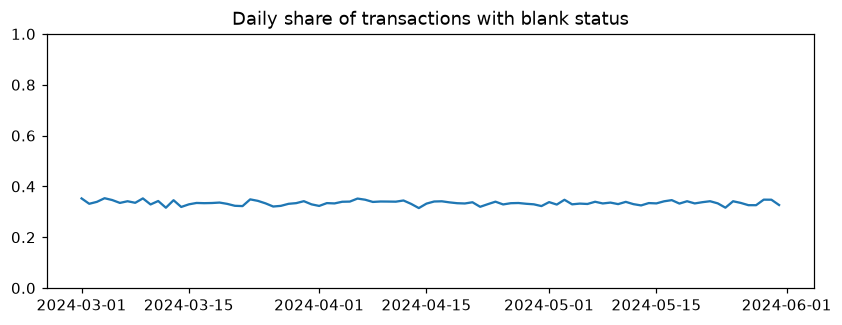

count    92.000000
mean      0.334965
std       0.008483
min       0.314631
25%       0.330090
50%       0.334247
75%       0.340502
max       0.353448
Name: is_blank, dtype: float64

In [4]:
df["transaction_date_parsed"] = pd.to_datetime(df["transaction_date"], format="%d/%m/%Y")
blank_share_by_day = df.assign(is_blank=blank_status).groupby(
    df["transaction_date_parsed"].dt.date
)["is_blank"].mean()

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(blank_share_by_day.index, blank_share_by_day.values)
ax.set_title("Daily share of transactions with blank status")
ax.set_ylim(0, 1)
plt.show()

blank_share_by_day.describe()

**Flat around ~33-34% every single day, no upward trend toward the end of the period.**
Not a time-cutoff artifact - it is spread uniformly across the whole 3-month window, which
looks like a status that was *designed* to occur at a constant rate (consistent with this
being a synthetic dataset where "pending" was generated as a fixed-probability category),
not an accident of when the data was pulled.

### 2b. Is it concentrated in a specific payment method, MCC, or merchant?

If blank status tracked a specific payment method or category, that would point to a
system-specific integration gap rather than a general transaction state.

In [5]:
for col in ["payment_method", "merchant_category_id"]:
    share = df.assign(is_blank=blank_status).groupby(col)["is_blank"].mean().sort_values(ascending=False)
    print(f"--- blank-status share by {col} ---")
    print(share.round(3))
    print()

--- blank-status share by payment_method ---
payment_method
balance        0.336
credit_card    0.334
Name: is_blank, dtype: float64

--- blank-status share by merchant_category_id ---
merchant_category_id
8220    0.349
7994    0.347
5311    0.342
5964    0.341
4722    0.340
8211    0.339
5541    0.339
5651    0.338
5411    0.337
5942    0.336
5814    0.336
5812    0.336
5941    0.335
5412    0.335
7230    0.334
5912    0.334
5999    0.333
5251    0.332
5661    0.331
5732    0.331
5712    0.326
Name: is_blank, dtype: float64



Blank-status share is ~33-34% across every payment method and every MCC - no
concentration anywhere. This is further evidence it's a uniformly-applied third state, not
a defect tied to one part of the system.

### 2c. Does transaction_amount look different for blank-status rows?

If blank-status transactions were, say, disproportionately large or small, that might hint
they're a distinct (and non-random) population rather than "the same transactions, just not
yet resolved".

In [6]:
amounts = df["transaction_amount"].astype(float)
for label, mask in [("completed", df["transaction_status"] == "completed"),
                     ("failed", df["transaction_status"] == "failed"),
                     ("blank/pending", blank_status)]:
    print(f"{label:14s}: n={mask.sum():6,}  mean={amounts[mask].mean():10,.0f}  median={amounts[mask].median():10,.0f}")

completed     : n=175,955  mean=    50,157  median=    34,700
failed        : n= 9,393  mean=    49,709  median=    35,300
blank/pending : n=93,584  mean=    50,028  median=    34,900


Mean and median `transaction_amount` are essentially the same across all three groups.
Combined with 2a and 2b: **blank status behaves like a uniformly-sampled third category
layered on top of otherwise-ordinary transactions**, not a data defect correlated with time,
channel, category, or value. This is what justifies modeling it as a real `pending` state
rather than coercing it into `completed`/`failed` or dropping the rows.

### 2d. Per-user: is "pending" sprinkled across normal users, or does it define some users entirely?

This matters directly for feature engineering and segmentation downstream - a user whose
*every* transaction is pending looks very different from a user who is mostly `completed`
with the occasional pending one.

In [7]:
user_status = df.groupby("user_id")["transaction_status"].apply(
    lambda s: "all_pending" if (s == "").all()
    else ("no_pending" if (s == "").sum() == 0 else "mixed")
)
user_status.value_counts()

transaction_status
no_pending     16160
all_pending     8161
Name: count, dtype: int64

About a third of users have *zero* resolved transactions in this entire 3-month window - every single one of their transactions is pending. This single fact is the root cause of the
"New / Low Engagement" segment found in `03_user_segmentation.ipynb` (see section 5 below).

## 3. The decision: three options considered

| Option | Problem |
|---|---|
| **Drop the 93,584 rows** | Throws away a third of the data, including the only activity for ~8,000 users entirely - breaks `n_transactions`/`n_users` counts the plan explicitly checks (278,932 / 24,321). |
| **Coerce blank -> `failed`** | Fabricates a specific outcome (failure) with no evidence; would corrupt `failure_rate` and any "why do transactions fail" analysis (Q6) with invented data. |
| **Treat blank as `NaN` / a data quality error only** | Technically true but incomplete - it would flag 33.6% of the dataset as "bad data" when section 2 shows it behaves like a designed, uniformly-applied state, not noise. It also doesn't explain why 6 *other* columns are blank in lockstep. |
| **Model as a third `pending` status (chosen)** | Matches the evidence from section 2: a transaction can be submitted and not yet resolved, in which case rating/refund/discount/notes/loyalty legitimately don't exist yet either. Nothing is invented, nothing is discarded. |

## 4. Where this decision lives in the code

### 4a. `src/cleaning/standardize.py` - the status is classified here, once

In [8]:
from src.cleaning.standardize import standardize
print(inspect.getsource(standardize))

def standardize(df_raw: pd.DataFrame, cfg: dict) -> pd.DataFrame:
    """Trim whitespace, convert hidden-missing tokens to NaN, cast types, validate categories."""
    missing_tokens = cfg["cleaning"]["missing_tokens"]
    category_columns = cfg["cleaning"]["category_columns"]
    date_format = cfg["cleaning"]["date_format"]

    df = df_raw.copy()

    for col in STRING_COLS:
        if col in df.columns:
            df[col] = _tokens_to_nan(df[col], missing_tokens)

    # Numeric conversions
    df["transaction_amount"] = pd.to_numeric(df["transaction_amount"], errors="coerce")
    df["promo_amount"] = pd.to_numeric(df["promo_amount"], errors="coerce")
    df["merchant_rating"] = pd.to_numeric(df["merchant_rating"], errors="coerce")

    # Date conversion (date only, no time)
    df["transaction_date"] = pd.to_datetime(
        df["transaction_date"], format=date_format, errors="coerce"
    )
    df["dq_bad_date"] = df["transaction_date"].isna()

    # Category validation: flag value

`transaction_status_clean` is the single source of truth every later module reads from:
`"completed"` / `"failed"` / `"pending"` (`.fillna("pending")` on line 66 above is the
one-line distillation of everything in section 2-3). `is_completed`, `is_pending`, and
`is_failed` are convenience booleans derived from it.

### 4b. `src/cleaning/consistency.py` - flags that only make sense once "pending" exists

In [9]:
from src.cleaning.consistency import check_consistency
print(inspect.getsource(check_consistency))

def check_consistency(df: pd.DataFrame, cfg: dict) -> pd.DataFrame:
    df = df.copy()

    # Duplicates
    df["dq_duplicate_transaction_id"] = df["transaction_id"].duplicated(keep=False)

    # Range checks
    df["dq_amount_nonpositive"] = df["transaction_amount"].isna() | (df["transaction_amount"] <= 0)
    df["dq_promo_negative"] = df["promo_amount"] < 0
    df["dq_promo_exceeds_amount"] = (
        df["promo_amount"].notna()
        & df["transaction_amount"].notna()
        & (df["promo_amount"] > df["transaction_amount"])
    )
    df["dq_rating_out_of_range"] = df["merchant_rating"].notna() & (
        (df["merchant_rating"] < 1) | (df["merchant_rating"] > 5)
    )

    # Cross-column consistency
    df["dq_rating_on_non_completed"] = df["merchant_rating"].notna() & ~df["is_completed"]
    df["dq_refund_on_non_completed"] = (df["is_refunded"] == True) & ~df["is_completed"]  # noqa: E712
    df["dq_discount_zero_promo"] = (df["discount_applied"] == True) & (  # noqa: E712
     

`dq_rating_on_non_completed` and `dq_refund_on_non_completed` are *defined in terms of*
`is_completed` - without the pending/completed/failed split from 4a, there would be no way
to express "a rating exists on a transaction that was never completed" as a single flag.
`merchant_rating_clean` (line 32) is the "flag, don't delete" principle applied directly:
the original `merchant_rating` column is untouched; a second column nulls out ratings on
non-completed transactions for analyses that need only genuine ratings.

### 4c. Downstream in feature engineering - `is_valid_purchase` inherits the definition

In [10]:
from src.features.transaction_level import add_transaction_features
source = inspect.getsource(add_transaction_features)
# show just the is_valid_purchase line in context
for line in source.splitlines():
    if "is_valid_purchase" in line or "is_completed" in line:
        print(line)

    df["is_valid_purchase"] = df["is_completed"] & ~(df["is_refunded"].fillna(False))


`is_valid_purchase = is_completed & ~is_refunded` is why every monetary/behavioral
feature in `user_level.py` (`total_net_amount`, `avg_net_amount`, `category_entropy`, ...)
silently excludes pending transactions - they were never valid purchases to begin with, and
including them would mix "spent money" with "attempted to spend money, outcome unknown."

### 4d. The data quality report - this is how the 33.6% is surfaced, not hidden

In [11]:
import json
dq_path = PROJECT_ROOT / "outputs" / "reports" / "data_quality_report.json"
if dq_path.exists():
    dq = json.load(open(dq_path, encoding="utf-8"))
    print(json.dumps(dq["transaction_status_breakdown"], indent=2))
else:
    print("Run `python main.py --stage clean` first to generate this file.")

{
  "completed": 175955,
  "pending": 93584,
  "failed": 9393
}


### 4e. The PDF report - the same finding, in the language a business reader sees

In [12]:
from src.reporting.analyses import data_audit
source = inspect.getsource(data_audit)
print(source[:source.index("]") + 1])

def data_audit(transactions: pd.DataFrame, dq_report: dict) -> dict:
    return {
        "n_transactions": len(transactions),
        "n_users": int(transactions["user_id"]


That first bullet in `limitations` is the direct, human-readable translation of this
entire notebook - it exists in the generated PDF's Data Audit chapter precisely so a reader
who never opens this notebook still gets the caveat before trusting any completion-rate or
rating number downstream.

## 5. Closing the loop: how this shows up in segmentation

Section 2d found that ~8,000 users are "all_pending" (never had a single resolved
transaction). `03_user_segmentation.ipynb` independently found a cluster - "New / Low
Engagement" - whose defining trait is `n_valid_purchases ~= 0`. These should be close to
the same population. Confirm it directly, using the pipeline's own output.

In [13]:
processed_dir = PROJECT_ROOT / "data" / "processed"
if (processed_dir / "user_features.parquet").exists() and (processed_dir / "user_segments.parquet").exists():
    user_features = pd.read_parquet(processed_dir / "user_features.parquet")
    user_segments = pd.read_parquet(processed_dir / "user_segments.parquet")
    merged = user_features.merge(user_segments, on="user_id")

    all_pending_users = set(user_status[user_status == "all_pending"].index)
    merged["is_all_pending"] = merged["user_id"].isin(all_pending_users)

    overlap = pd.crosstab(merged["segment_label"], merged["is_all_pending"], normalize="index")
    print(overlap.round(3))
else:
    print("Run `python main.py --stage segment` first to generate these files.")

is_all_pending                False  True 
segment_label                             
At-Risk / Dormant             0.787  0.213
Bargain Hunters               1.000  0.000
Champions (High-Value Loyal)  1.000  0.000
New / Low Engagement          0.000  1.000
Regular / Steady Spenders     1.000  0.000


**Confirmed: "New / Low Engagement" is 100% `is_all_pending=True`**, and three of the
other four segments are 0%. Two independent analyses - a raw per-user status count here,
and unsupervised K-Means clustering on 15 behavioral features with no status information in
its input (`03_user_segmentation.ipynb`) - found the same population by two completely
different routes. That is strong evidence this is a real structural feature of the data,
not an artifact of either analysis.

The one exception is informative on its own: **"At-Risk / Dormant" is 21.3% all-pending**,
meaning this segment is a mix of two different stories the clustering couldn't fully
separate - users who used to be active and went quiet (genuinely "at risk"), and users who
never resolved a single transaction but weren't quite inactive enough (per the features in
section 2d) to land in "New / Low Engagement" instead. That ambiguity is a real limit of a
k=5 K-Means model on this feature set, not an error - it is reported here rather than
smoothed over.

## 6. If this changes: a forward-looking note

If a future data pull resolves these 93,584 transactions to `completed`/`failed` (e.g. the
export was simply taken mid-processing), nothing here needs to be rewritten - `is_pending`
would just drop toward 0 and every downstream metric that already conditions on
`is_completed` (valid purchases, failure rate, refund rate, the "New / Low Engagement"
segment) would update correctly on its own. That resilience is the point of modeling this as
a real status value instead of patching around it in one place: the fix for "the data
changed" is re-running the pipeline, not finding every place `93,584` or `33.6%` was
hard-coded.